In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('mymoviedb.csv', engine='python')

In [5]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [7]:
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [9]:
df['Release_Date']=pd.to_datetime(df['Release_Date'], errors='coerce')

In [10]:
df['Vote_Count']=pd.to_numeric(df['Vote_Count'], errors='coerce')

In [11]:
df['Vote_Average']=pd.to_numeric(df['Vote_Average'], errors='coerce')

In [12]:
df.isnull().sum()

Release_Date         10
Title                 9
Overview              9
Popularity           10
Vote_Count           11
Vote_Average         11
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9828 non-null   object        
 2   Overview           9828 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9826 non-null   float64       
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9827 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(5)
memory usage: 691.8+ KB


In [14]:
df.duplicated().sum()

np.int64(8)

In [21]:
df=df.dropna()
df=df.drop_duplicates()

In [23]:
print(df.shape)

(9826, 9)


In [24]:
df.describe().round(2)

,Release_Date,Popularity,Vote_Count,Vote_Average
count,9826,9826.00,9826.00,9826.00
mean,2006-09-23 04:47:14.276409600,40.32,1392.94,6.44
min,1902-04-17 00:00:00,13.35,0.00,0.00
25%,2000-10-17 12:00:00,16.13,146.00,5.90
50%,2011-09-12 00:00:00,21.20,444.00,6.50
75%,2017-11-22 00:00:00,35.18,1376.00,7.10
max,2024-07-03 00:00:00,5083.95,31077.00,10.00
std,NaN,108.88,2611.30,1.13


In [25]:
df.drop(columns=['Overview', 'Poster_Url'], inplace=True)

In [26]:
df['Release_Date']=df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [27]:
df.rename(columns={'Release_Date':'Release_Year'}, inplace=True)

In [28]:
df['Vote_Average'].dtype

dtype('float64')

In [29]:
def categorize_col(df, col, labels):
    edges=[df[col].describe()['min'],
           df[col].describe()['25%'],
           df[col].describe()['50%'],
           df[col].describe()['75%'],
           df[col].describe()['max']]
    df[col]=pd.cut(df[col],edges, labels= labels, duplicates='drop')
    return df

In [30]:
labels = ['Low Rated','Average Rated','Well Rated','Highly Rated']
categorize_col(df, 'Vote_Average', labels)

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,Highly Rated,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,Average Rated,en,Thriller
3,2021,Encanto,2402.201,5076.0,Highly Rated,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,Well Rated,en,"Action, Adventure, Thriller, War"
...,...,...,...,...,...,...,...
9832,1973,Badlands,13.357,896.0,Highly Rated,en,"Drama, Crime"
9833,2020,Violent Delights,13.356,8.0,Low Rated,es,Horror
9834,2016,The Offering,13.355,94.0,Low Rated,en,"Mystery, Thriller, Horror"
9835,2021,The United States vs. Billie Holiday,13.354,152.0,Well Rated,en,"Music, Drama, History"


In [31]:
df.head()

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,Highly Rated,en,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,Average Rated,en,Thriller
3,2021,Encanto,2402.201,5076.0,Highly Rated,en,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,Well Rated,en,"Action, Adventure, Thriller, War"


In [32]:
df['Vote_Average'].value_counts()

Vote_Average
Low Rated        2467
Highly Rated     2450
Well Rated       2411
Average Rated    2398
Name: count, dtype: int64

In [33]:
df['Genre']=df['Genre'].str.split(', ')

df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,Science Fiction
3,2022,The Batman,3827.658,1151.0,Highly Rated,en,Crime
4,2022,The Batman,3827.658,1151.0,Highly Rated,en,Mystery


In [34]:
df['Genre']=df['Genre'].astype('category')

# Data visualization

In [35]:
sns.set_style('whitegrid')

# What is the most frequent movie genre?

In [36]:
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

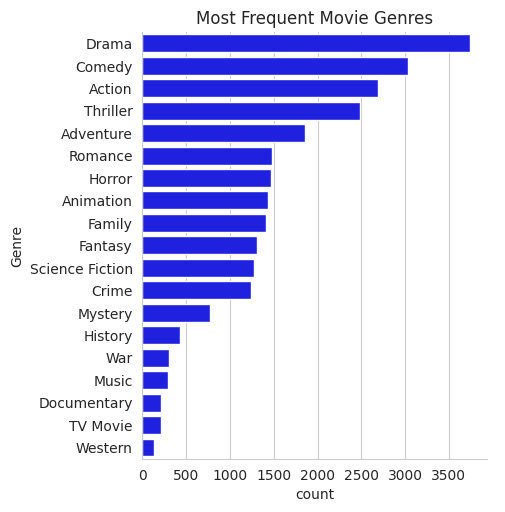

In [37]:
sns.catplot(y='Genre', data=df, kind='count',
           order=df['Genre'].value_counts().index,
           color='Blue')
plt.title('Most Frequent Movie Genres')
plt.show()

# How are movie releases distributed across years?

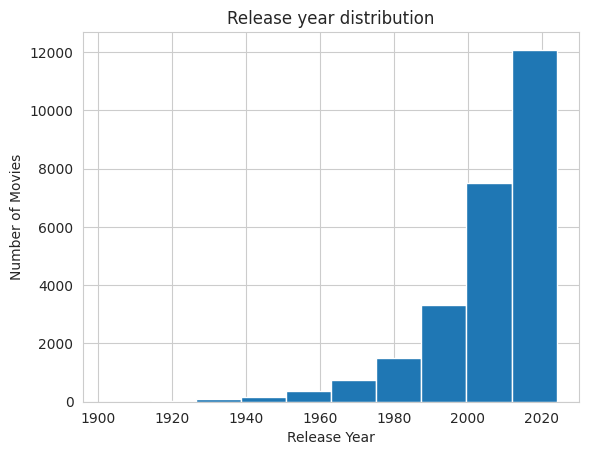

In [38]:
df['Release_Year'].hist()
plt.title('Release year distribution')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.show()

# Which movie recorded highest popularity?

In [39]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,Highly Rated,en,Science Fiction


# Which movie recorded lowest popularity?

In [40]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Year,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre
25786,2021,The United States vs. Billie Holiday,13.354,152.0,Well Rated,en,Music
25787,2021,The United States vs. Billie Holiday,13.354,152.0,Well Rated,en,Drama
25788,2021,The United States vs. Billie Holiday,13.354,152.0,Well Rated,en,History
25789,1984,Threads,13.354,186.0,Highly Rated,en,War
25790,1984,Threads,13.354,186.0,Highly Rated,en,Drama
25791,1984,Threads,13.354,186.0,Highly Rated,en,Science Fiction


# Which rating category is most common?

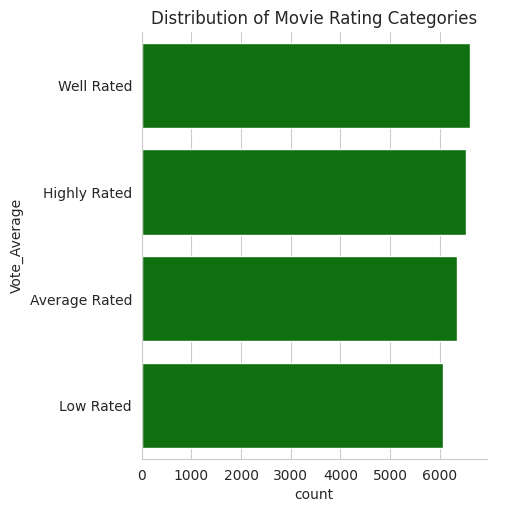

In [41]:
sns.catplot(y='Vote_Average', data=df, kind='count',
           order=df['Vote_Average'].value_counts().index,
           color='Green')
plt.title('Distribution of Movie Rating Categories')
plt.show()